In [8]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/alexandersoriapadilla-cell/Estadistica-Verano-2026/refs/heads/main/StudentPerformance/Student_Performance.csv")

df

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


Establecemos las horas de estudio (Hours Studied) como variable dependiente y el índice de desempeño ("Performance _Index") como la variable dependiente. Esto es porque la hipótesis inicial es que cambios en las horas de estudio puede cambiar cambios en el índice de desempeño, sin embargo cambios en los índices de desempeño no causa cambios en las horas de estudio.
↑

In [9]:
X = df["Hours_Studied"] #Variable independiente
y = df["Performance_Index"] #Variable depediente

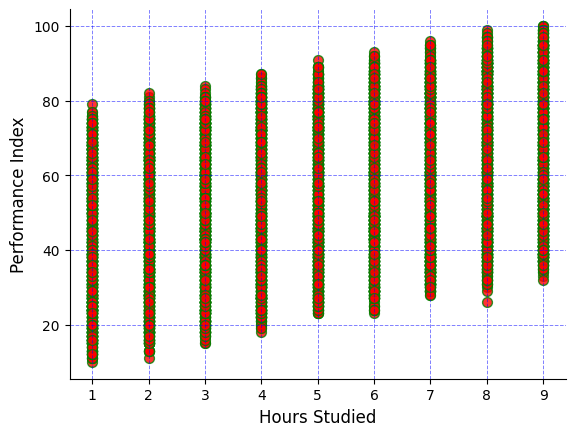

In [10]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Definimos las variables X e Y a partir del DataFrame
X = df["Hours_Studied"]
Y = df["Performance_Index"]

# Configuración general del gráfico
# The lines below are redundant as X and Y are already defined above.
# X = df["promedio_examenes_cortos"]
# Y = df["promedio_final"]          # resolución del gráfico

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='red',     # color de los puntos
    edgecolor='green',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50                  # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Hours Studied', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Performance Index', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)

# Mostrar el gráfico
plt.show()

El gráfico de dispersión muestra una clara tencencia lineal. Se puede observar que conforme aumentan las horas de estudio (X) aumenta el índice de desempeño (Y). Con lo que se espera un coeficiente de correlación positivo y parece cumplirse el supuesto de linealidad.


In [11]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.3737
valor_p:  0.0000


El coeficiente de relacion $r= 0.3737$ muestra una correlacion lineal debil, sin embargo la prueba de hipotesis indica que si hay correlación

In [12]:
import statsmodels.api as sm
x_constante = sm.add_constant (X)
modelo = sm.OLS (Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,41.379175
Hours_Studied,2.773063


In [13]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  13.97%


Ya ajutado el modelo de regresion lineal se obtiene un coeficiente dedeterminación de $R^2=0.1397$. Entonces teniendo horas de estudi y de modelo ajustado, solo podemos justificar la variabiliad en las alificacione un 13.97%, lo que es bajo para poder realizar predicciones precisas